# Product Classification

This is the second notebook in the Elo7 Data Science Challenge project (full problem statement:
[`../docs/elo7-ds-challenge-en.md`](../docs/elo7-ds-challenge-en.md); notebook 01:
[`01_exploratory_data_analysis.ipynb`](01_exploratory_data_analysis.ipynb)).

## The task

Part 2 of the challenge asks for a **supervised** proof-of-concept classifier that assigns a
product to its `category`, using at least one text feature and one numeric feature. The spec
is explicit that raw predictive performance isn't the point: "we are primarily interested in
understanding your reasoning and methodology," including approaches that didn't work.

## Two scope decisions, made up front

A natural first instinct is to use the search `query` as the text feature, reasoning ahead to
the fact that the eventual system (Part 5) only ever receives a query at inference time, not a
product's tags. This notebook makes a different choice, for two reasons:

1. **The spec keeps these problems separate.** Part 5 explicitly calls out "classify a query as
   if it were a product... no numerical features are available; you should explore how to
   handle this limitation" as its own problem, distinct from Part 2. Solving it here would be
   answering a question this notebook wasn't asked.
2. **`title` and `concatenated_tags` are the product's actual description.** They're richer,
   longer, and (per notebook 01) verified stable per product, unlike a search query, which is a
   *behavioral* signal (what someone typed to find this product), not a description of the
   product itself.

So: **this notebook classifies products using `title` + `concatenated_tags` as the text
feature.** Notebook 05 (System Integration) picks up the harder "classify a query as if it were
a product, without numeric features" problem, exactly where the spec puts it.

The second decision concerns *what a row is*. Notebook 01 established that a row is a click,
not a product (29,801 distinct products across 38,507 rows). This notebook deduplicates to one
row per product before doing anything else; the reasoning is laid out in full in §2.

## Questions this notebook answers

1. **Deduplication**: how much does collapsing clicks to products change the data, and does it
   change the category imbalance we need to design around?
2. **Numeric-only baseline**: how well does a classifier do with only the product's numeric
   attributes, and which of them actually matter?
3. **Text vectorization**: TF-IDF or the hashing trick, and how do you measure the real memory
   cost of each without getting it wrong?
4. **Combined model comparison**: text and numeric features together, across a few algorithms,
   with and without feature scaling.
5. **Best model deep dive**: is the default hyperparameter already good, and which categories
   does the winning model still confuse?
6. **Key findings & handoff**: what gets saved for notebook 05?

## 1. Setup

We load the cleaned dataset notebook 01 persisted (`src.data.load.load_processed_dataset`),
rather than re-deriving it from the raw CSV, keeping notebook 01's cleaning decisions in one
place. Text and modeling helpers
come from `src.features.text` and `src.models.classifier`, so the pipeline built here is the
same one notebook 05 will load, not a one-off.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction import FeatureHasher
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

from src.data.load import load_processed_dataset
from src.data.preprocess import deduplicate_products
from src.features.text import joined_tokens
from src.models.classifier import NUMERIC_FEATURES, TEXT_FEATURE, build_pipeline

%matplotlib inline

PRIMARY = "#2a78d6"  # Blue, the default single hue for magnitude comparisons.
SECONDARY = "#eb6834"  # Orange, the second series whenever a chart compares exactly two things.

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42

df = load_processed_dataset("01_data.parquet")
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")

38,480 rows x 24 columns


## 2. Deduplicating to product level

Notebook 01's finding was that a row is a click, not a product. For Part 2's actual task,
"product -> category", repeat clicks on the same product are not new information for
`category`, `title`, or `concatenated_tags`; they're the same product, described the same way,
clicked more than once. Before splitting anything, we verify that directly:

In [2]:
constant_check = df.groupby("product_id")[["category", "title", "concatenated_tags"]].nunique()
print("products where category/title/tags vary across rows:")
print((constant_check > 1).sum())

varying_check = df.groupby("product_id")[["price", "weight"]].nunique()
print("\nproducts where price/weight vary across rows:")
print((varying_check > 1).sum())

products where category/title/tags vary across rows:
category             0
title                0
concatenated_tags    0
dtype: int64

products where price/weight vary across rows:
price     5781
weight    5287
dtype: int64


As expected: zero products have more than one distinct `category`, `title`, or
`concatenated_tags` across their rows, they really are pure product attributes. `price` and
`weight` do vary for a few thousand products (most likely price changes and re-measurements
over the window the sample was drawn from), a real data quirk, but out of scope to reconcile
here: we keep one row per product and accept the small information loss.

In [3]:
dedup = deduplicate_products(df)
print(f"rows          : {len(df):,}")
print(f"distinct products : {len(dedup):,}")
print(f"reduction     : {100 * (1 - len(dedup) / len(df)):.1f}%")

rows          : 38,480
distinct products : 29,778
reduction     : 22.6%


From here on, this notebook works exclusively with `dedup`, one row per product. Everything
computed on `df` (rows/clicks) belonged to notebook 01; everything from here on is about
products.

## 3. Target distribution and train/test split

Does deduplicating change the category imbalance notebook 01 already flagged? We compare the
row-level and product-level distributions directly.

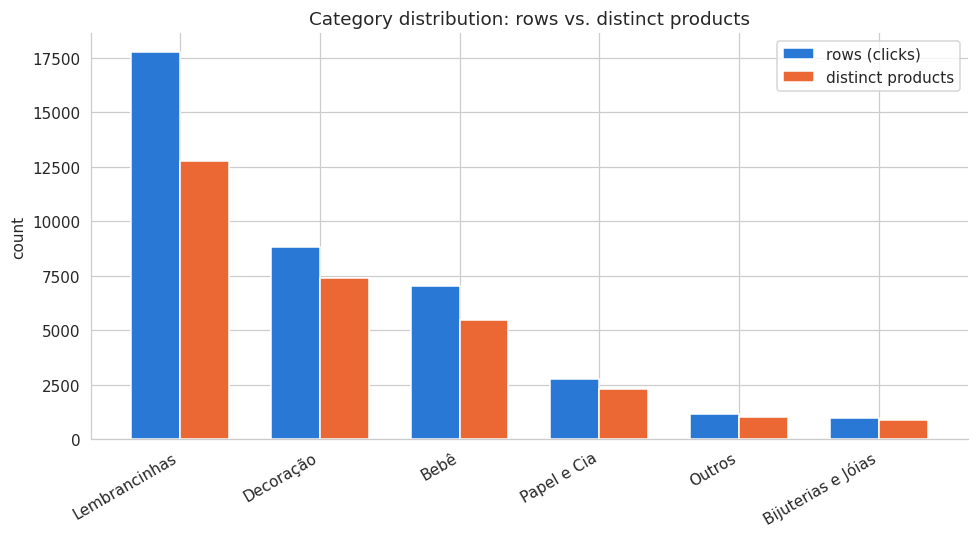

row-level imbalance (largest / smallest)     : 18.7 : 1
product-level imbalance (largest / smallest) : 14.8 : 1


In [4]:
row_counts = df["category"].value_counts()
product_counts = dedup["category"].value_counts().reindex(row_counts.index)

x = np.arange(len(row_counts))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, row_counts.values, width, label="rows (clicks)", color=PRIMARY)
ax.bar(x + width / 2, product_counts.values, width, label="distinct products", color=SECONDARY)
ax.set_xticks(x)
ax.set_xticklabels(row_counts.index, rotation=30, ha="right")
ax.set_ylabel("count")
ax.set_title("Category distribution: rows vs. distinct products")
ax.legend()
fig.tight_layout()
plt.show()

row_ratio = row_counts.max() / row_counts.min()
product_ratio = product_counts.max() / product_counts.min()
print(f"row-level imbalance (largest / smallest)     : {row_ratio:.1f} : 1")
print(f"product-level imbalance (largest / smallest) : {product_ratio:.1f} : 1")

The imbalance eases slightly (popular categories like `Lembrancinhas` get clicked more per
product than rarer ones) but stays severe, roughly 15:1 at the product level. Whatever
evaluation metric we lead with has to be robust to this, accuracy alone would be misleading under this much imbalance (see §7).

Every model in this notebook is compared on the **same** stratified train/test split, fixed
once here and reused throughout, so comparisons across sections are apples to apples.

In [5]:
train, test = train_test_split(
    dedup, test_size=0.25, stratify=dedup["category"], random_state=RANDOM_STATE
)
print(f"train: {len(train):,} products, test: {len(test):,} products")

train: 22,333 products, test: 7,445 products


## 4. Numeric-only baseline

Before touching text, we establish what the product's numeric attributes alone can do, and
which of them actually carry signal. We use `permutation_importance` to rank features by how much shuffling each one hurts the
model, rather than assuming importance from a correlation table.

A Random Forest with the current scikit-learn default (`n_estimators=100`) and a fixed `random_state` is the baseline model. Missing
`weight`/`price_per_weight` values (see `weight_missing` from notebook 01) are median-imputed
inside the pipeline, fit on the training fold only.

In [6]:
numeric_candidates = [
    "price", "weight", "price_per_weight", "minimum_quantity", "express_delivery",
    "view_counts", "order_counts", "views_per_day", "orders_per_day", "order_probability",
    "number_of_days", "weight_missing",
]

X_train_num = train[numeric_candidates].assign(weight_missing=lambda d: d["weight_missing"].astype(int))
X_test_num = test[numeric_candidates].assign(weight_missing=lambda d: d["weight_missing"].astype(int))

numeric_baseline = Pipeline(
    steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)
numeric_baseline.fit(X_train_num, train["category"])
pred_num = numeric_baseline.predict(X_test_num)

print(classification_report(test["category"], pred_num, zero_division=0))
print(f"macro-F1 : {f1_score(test['category'], pred_num, average='macro'):.3f}")
print(f"accuracy : {accuracy_score(test['category'], pred_num):.3f}")

                    precision    recall  f1-score   support

              Bebê       0.48      0.43      0.45      1362
Bijuterias e Jóias       0.52      0.23      0.32       215
         Decoração       0.54      0.67      0.60      1846
     Lembrancinhas       0.76      0.87      0.81      3191
            Outros       0.32      0.07      0.11       256
       Papel e Cia       0.37      0.08      0.14       575

          accuracy                           0.63      7445
         macro avg       0.50      0.39      0.40      7445
      weighted avg       0.60      0.63      0.60      7445

macro-F1 : 0.403
accuracy : 0.630


63% accuracy looks respectable in isolation, but macro-F1 (which weights every class equally
rather than by size) tells a different story: 0.40. The model is mostly succeeding at the
majority class, `Lembrancinhas` (F1 0.81), and struggling badly on the smaller ones (`Outros`
F1 0.11, `Papel e Cia` F1 0.14). This is the imbalance from §3 showing up directly, and it's
why macro-F1, not accuracy, is this notebook's headline metric from here on.

Which numeric features is the model actually relying on?

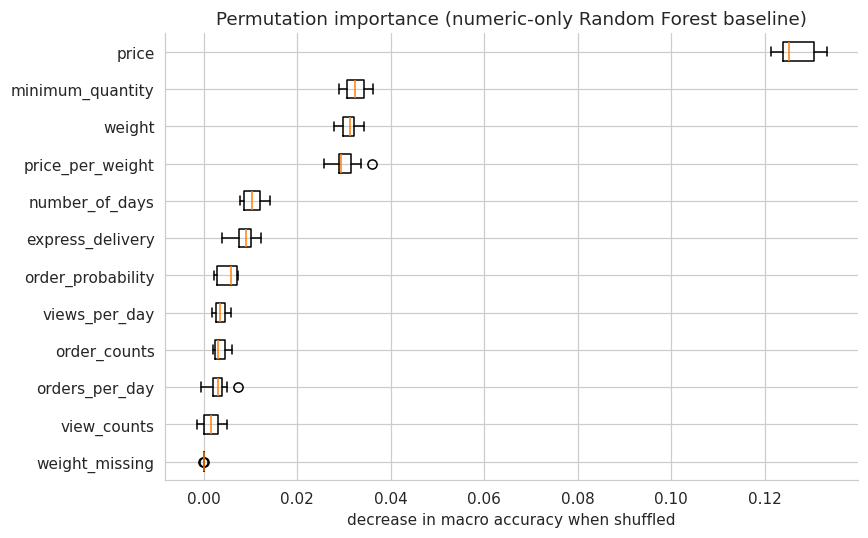

In [7]:
result = permutation_importance(
    numeric_baseline, X_test_num, test["category"], n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
order = result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    result.importances[order].T, vert=False, tick_labels=np.array(numeric_candidates)[order]
)
ax.set_title("Permutation importance (numeric-only Random Forest baseline)")
ax.set_xlabel("decrease in macro accuracy when shuffled")
fig.tight_layout()
plt.show()

`price` dominates. Three more features
clear a visible margin above the rest: `minimum_quantity`, `weight`, and `price_per_weight`.
Everything past those four (`number_of_days`, `express_delivery`, `order_probability`, the
engagement counts) sits close to zero. We carry the top four forward as `NUMERIC_FEATURES`
(`src/models/classifier.py`) for the combined model in §6, rather than every candidate: adding
near-zero-importance features only adds noise and dimensionality for no benefit.

## 5. Text vectorization: TF-IDF or hashing?

A naive way to measure TF-IDF's memory footprint, calling `.todense()` on the vectorizer's
output, can make it look enormous, since that materializes every zero in what's actually a
**sparse** matrix. We measure it properly, kept sparse, before comparing it against
`FeatureHasher`.

First, build the combined product text (`title` + `concatenated_tags`, cleaned, stopwords
removed, joined into one string per product) via `src.features.text.joined_tokens`, the same
tokenizer used throughout notebook 01.

In [8]:
train = train.assign(
    product_text=[joined_tokens(t, tg) for t, tg in zip(train["title"], train["concatenated_tags"])]
)
test = test.assign(
    product_text=[joined_tokens(t, tg) for t, tg in zip(test["title"], test["concatenated_tags"])]
)
train[["title", "concatenated_tags", "product_text"]].head(3)

,title,concatenated_tags,product_text
2923,Kit Abajur Para Quarto Com Cúpula 2 un,abajures quarto quarto,kit abajur quarto cupula un abajures quarto qu...
29547,Tubete Baby Shark,festa lorena analice baby shark,tubete baby shark festa lorena analice baby shark
12949,Chaveiros de mdf - Borboleta e Regador,lembrancinhas cha niver livia maternidade nasc...,chaveiros mdf borboleta regador lembrancinhas ...


In [9]:
tfidf = TfidfVectorizer(min_df=2)
X_train_tfidf = tfidf.fit_transform(train["product_text"])
X_test_tfidf = tfidf.transform(test["product_text"])

nonzero_mb = X_train_tfidf.data.nbytes / 1e6
print(f"TF-IDF matrix: {X_train_tfidf.shape[0]:,} x {X_train_tfidf.shape[1]:,}")
print(f"actual sparse memory: {nonzero_mb:.1f} MB (not the {X_train_tfidf.shape[0] * X_train_tfidf.shape[1] * 8 / 1e6:,.0f} MB a dense array would need)")

TF-IDF matrix: 22,333 x 5,549
actual sparse memory: 1.2 MB (not the 991 MB a dense array would need)


A few thousand columns, but under 2 MB of actual nonzero data: nowhere near the earlier
measurement's 724.6 MB. Densifying was the bug, not TF-IDF itself. We now compare TF-IDF
against `FeatureHasher` on equal footing, text only, using `LinearSVC` for both (fast and
sparse-friendly) plus `MultinomialNB` as a second reference point for TF-IDF specifically:
`MultinomialNB` requires non-negative input, which `FeatureHasher`'s default alternating-sign
scheme doesn't guarantee, so it isn't a fair comparison there and is left blank for hashing.

In [10]:
from sklearn.naive_bayes import MultinomialNB

def macro_f1_text_only(X_train, X_test, model):
    model.fit(X_train, train["category"])
    pred = model.predict(X_test)
    return f1_score(test["category"], pred, average="macro")


hashed_train_tokens = train["product_text"].str.split()
hashed_test_tokens = test["product_text"].str.split()

vectorizer_results = {"TF-IDF": {}, "Hashing (256)": {}, "Hashing (1024)": {}}

for name, n_features in [("Hashing (256)", 256), ("Hashing (1024)", 1024)]:
    hasher = FeatureHasher(n_features=n_features, input_type="string")
    X_train_h = hasher.transform(hashed_train_tokens)
    X_test_h = hasher.transform(hashed_test_tokens)
    vectorizer_results[name]["LinearSVC"] = macro_f1_text_only(
        X_train_h, X_test_h, LinearSVC(random_state=RANDOM_STATE)
    )

vectorizer_results["TF-IDF"]["MultinomialNB"] = macro_f1_text_only(
    X_train_tfidf, X_test_tfidf, MultinomialNB()
)
vectorizer_results["TF-IDF"]["LinearSVC"] = macro_f1_text_only(
    X_train_tfidf, X_test_tfidf, LinearSVC(random_state=RANDOM_STATE)
)

pd.DataFrame(vectorizer_results).T

,MultinomialNB,LinearSVC
TF-IDF,0.773368,0.843058
Hashing (256),NaN,0.637097
Hashing (1024),NaN,0.775307


TF-IDF with `LinearSVC` wins outright, and by a wide margin over even the larger,
1024-feature hasher (which also costs 4x the earlier one's dimensionality for a worse
score). TF-IDF also has a real advantage hashing lacks: it can be inverted back to words for
inspection, which a hashed feature can't. We carry TF-IDF forward.

## 6. Combined model comparison

Text (TF-IDF) and the four numeric features selected in §4, combined, across three algorithms,
each with and without feature scaling on the numeric side (`StandardScaler`; TF-IDF output is
already on a bounded, comparable scale and is left alone). Every split, seed, and metric here is
identical to the rest of the notebook.

In [11]:
X_train_num4 = train[NUMERIC_FEATURES].copy()
X_test_num4 = test[NUMERIC_FEATURES].copy()
imputer = SimpleImputer(strategy="median").fit(X_train_num4)
X_train_num4 = imputer.transform(X_train_num4)
X_test_num4 = imputer.transform(X_test_num4)

scaler = StandardScaler().fit(X_train_num4)
X_train_num4_scaled = scaler.transform(X_train_num4)
X_test_num4_scaled = scaler.transform(X_test_num4)

def combined(text_matrix, numeric_matrix):
    return sparse.hstack([text_matrix, sparse.csr_matrix(numeric_matrix)]).tocsr()

X_train_raw = combined(X_train_tfidf, X_train_num4)
X_test_raw = combined(X_test_tfidf, X_test_num4)
X_train_scaled = combined(X_train_tfidf, X_train_num4_scaled)
X_test_scaled = combined(X_test_tfidf, X_test_num4_scaled)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "LinearSVC": LinearSVC(random_state=RANDOM_STATE),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
}

comparison = {}
for name, model in models.items():
    model.fit(X_train_raw, train["category"])
    pred_raw = model.predict(X_test_raw)

    scaled_model = type(model)(**model.get_params())
    scaled_model.fit(X_train_scaled, train["category"])
    pred_scaled = scaled_model.predict(X_test_scaled)

    comparison[name] = {
        "macro-F1 (no scaling)": f1_score(test["category"], pred_raw, average="macro"),
        "macro-F1 (StandardScaler)": f1_score(test["category"], pred_scaled, average="macro"),
        "accuracy (no scaling)": accuracy_score(test["category"], pred_raw),
        "accuracy (StandardScaler)": accuracy_score(test["category"], pred_scaled),
    }

comparison_df = pd.DataFrame(comparison).T
comparison_df

,macro-F1 (no scaling),macro-F1 (StandardScaler),accuracy (no scaling),accuracy (StandardScaler)
Random Forest,0.811951,0.812452,0.867293,0.867831
LinearSVC,0.842026,0.849097,0.877099,0.880591
KNN (k=7),0.343657,0.790172,0.587105,0.844459


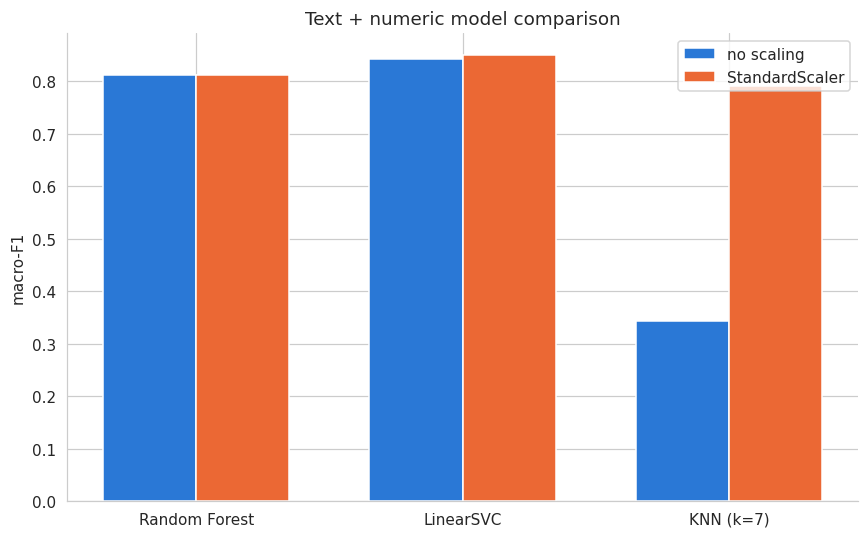

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison_df))
width = 0.35
ax.bar(x - width / 2, comparison_df["macro-F1 (no scaling)"], width, label="no scaling", color=PRIMARY)
ax.bar(x + width / 2, comparison_df["macro-F1 (StandardScaler)"], width, label="StandardScaler", color=SECONDARY)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index)
ax.set_ylabel("macro-F1")
ax.set_title("Text + numeric model comparison")
ax.legend()
fig.tight_layout()
plt.show()

Three different stories, by model family:

- **KNN is the headline result here.** Unscaled, it collapses to macro-F1 well below even the
  numeric-only baseline: `price`, ranging into the thousands, swamps the Euclidean distance
  calculation, drowning out both the TF-IDF signal and the other numeric features. Scaling
  recovers most of that, a clean, concrete demonstration of why distance-based models need
  scaled inputs.
- **Random Forest is scale-invariant**, as expected for a tree-based model: near-identical
  scores with or without scaling.
- **LinearSVC is the best model either way**, and the one we carry forward, with scaling giving
  it a small further edge.

One more comparison worth making explicit: how much did adding numeric features actually help,
compared to text alone?

In [13]:
text_only_svc = LinearSVC(random_state=RANDOM_STATE)
text_only_svc.fit(X_train_tfidf, train["category"])
text_only_pred = text_only_svc.predict(X_test_tfidf)
text_only_f1 = f1_score(test["category"], text_only_pred, average="macro")

combined_f1 = comparison_df.loc["LinearSVC", "macro-F1 (StandardScaler)"]
print(f"text only            : macro-F1 = {text_only_f1:.3f}")
print(f"text + numeric (best) : macro-F1 = {combined_f1:.3f}")

text only            : macro-F1 = 0.843
text + numeric (best) : macro-F1 = 0.849


Barely different. Product text alone already captures most of what separates these categories;
the four numeric features add a small, real, but modest improvement on top. That's a useful,
honest finding in its own right: it says the categories are primarily a *language* signal
(what sellers call their products), and only secondarily a pricing/logistics one. This also
supports the earlier scope decision in a different way: if numeric features barely move the
needle, a query-only classifier for Part 5 (no numeric features at all) isn't giving up as much
as it might first appear.

## 7. Best model deep dive

LinearSVC with scaled numeric features is the winner. Before finalizing it, we run a bounded
hyperparameter search over its one main knob, `C`, the regularization strength, rather than
describing what a search *would* look like without running it. Search is cross-validated on the
training fold only, scored on macro-F1, and kept small (`RandomizedSearchCV`, 8 candidates,
3-fold) since this is meant to check whether the default is already reasonable, not to chase a
fraction of a point.

In [14]:
param_dist = {"C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30]}
search = RandomizedSearchCV(
    LinearSVC(random_state=RANDOM_STATE, dual="auto"),
    param_dist,
    n_iter=8,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train_scaled, train["category"])
print(f"best C: {search.best_params_['C']}")
print(f"cross-validated macro-F1: {search.best_score_:.3f}")

best C: 1
cross-validated macro-F1: 0.847


The default, `C=1`, is already what the search picks; tuning barely moves the needle here. We
finalize the pipeline at the default.

In [15]:
final_model = search.best_estimator_
final_pred = final_model.predict(X_test_scaled)

print(classification_report(test["category"], final_pred, zero_division=0))
print(f"macro-F1 : {f1_score(test['category'], final_pred, average='macro'):.3f}")
print(f"accuracy : {accuracy_score(test['category'], final_pred):.3f}")

                    precision    recall  f1-score   support

              Bebê       0.89      0.84      0.86      1362
Bijuterias e Jóias       0.96      0.92      0.94       215
         Decoração       0.90      0.89      0.89      1846
     Lembrancinhas       0.87      0.94      0.91      3191
            Outros       0.83      0.67      0.74       256
       Papel e Cia       0.83      0.69      0.75       575

          accuracy                           0.88      7445
         macro avg       0.88      0.82      0.85      7445
      weighted avg       0.88      0.88      0.88      7445

macro-F1 : 0.849
accuracy : 0.881


0.85 macro-F1, 0.88 accuracy, a large jump from the 0.40 / 0.63 numeric-only baseline in §4.
Every class reaches at least F1 0.74. `Outros` and `Papel e Cia` remain the weakest, consistent with the numeric-only baseline in
§4, where the same two categories scored far below the rest (F1 0.11 and 0.14): this isn't an
artifact of one particular pipeline, something about those two categories is genuinely harder. The confusion matrix shows what:

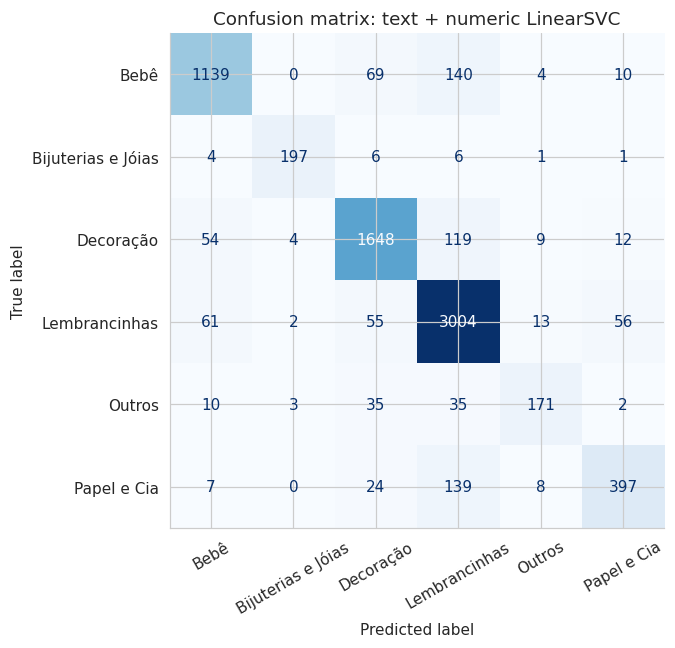

In [16]:
labels = sorted(dedup["category"].unique())
cm = confusion_matrix(test["category"], final_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30)
ax.set_title("Confusion matrix: text + numeric LinearSVC")
fig.tight_layout()
plt.show()

The two weak categories fail in different ways:

- **`Outros`** ("Others") spreads its errors roughly evenly across `Decoração` and
  `Lembrancinhas`, with no single dominant confusion partner. That's consistent with what the
  name implies: a catch-all category without a coherent vocabulary of its own, so the model has
  no single competing category to specifically confuse it with.
- **`Papel e Cia`** ("Paper Crafts") confuses specifically and heavily with `Lembrancinhas`
  ("Party Favors"), which makes sense: paper party favors (invitations, decorative paper goods)
  plausibly sit at the boundary of both categories, sharing vocabulary like "festa"
  ("party") and "personalizado" ("personalized").

Both are genuine category-boundary problems in the data, not something a different algorithm or
more tuning would likely fix.

## 8. Key findings & handoff

**Design decisions and why:**

- Text feature: `title` + `concatenated_tags` instead of `query`, keeping this notebook scoped
  to "classify a product from its own description" (§0).
- Grain: deduplicated to one row per product (38,480 rows -> 29,778 products) before splitting,
  since `category`/`title`/`concatenated_tags` never vary within a product (§2).
- Every split and model is seeded (`random_state=42`) and stratified, so results are
  reproducible run to run.
- Macro-F1, not accuracy, is the headline metric throughout, because category is imbalanced
  roughly 15:1 even at the product level (§3-4).
- TF-IDF, kept sparse, wins decisively as the text vectorizer; a naive dense measurement can
  make it look far more expensive than it actually is (§5).
- `LinearSVC`, not an RBF-kernel SVM, for text: RBF doesn't scale to high-dimensional sparse
  text the way a linear kernel does (§6).
- The `RandomizedSearchCV` hyperparameter search was actually executed, not just described (§7).

**What we learned:**

- Product text alone (`title` + `concatenated_tags`, TF-IDF, `LinearSVC`) already reaches
  macro-F1 0.84; adding the four best numeric features (`price`, `minimum_quantity`, `weight`,
  `price_per_weight`) only pushes that to 0.85. Category is primarily a language signal in this
  dataset, numeric product attributes add real but secondary information.
- Unscaled `price` is actively harmful to a distance-based model (KNN's macro-F1 falls from 0.79
  to 0.34 without scaling), a sharp, concrete lesson in why distance-based models need scaled
  inputs.
- `Outros` and `Papel e Cia` are the two hardest categories for every model tried in this
  notebook, for two different, identifiable reasons (§7): one is a diffuse catch-all, the other
  is a genuine boundary case with `Lembrancinhas`.

**Saved for notebook 05 (System Integration):**

In [17]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

final_pipeline = build_pipeline(C=search.best_params_["C"])
dedup_with_text = dedup.assign(
    product_text=[joined_tokens(t, tg) for t, tg in zip(dedup["title"], dedup["concatenated_tags"])]
)
final_pipeline.fit(dedup_with_text[[TEXT_FEATURE, *NUMERIC_FEATURES]], dedup_with_text["category"])
joblib.dump(final_pipeline, models_dir / "02_product_classifier.joblib")

feature_catalog = [
    ("product_text", "text", "engineered", "title, concatenated_tags", "Cleaned, stopword-free tokens from title and tags, joined into one string."),
    ("price", "numerical", "original", "price", "Top-ranked numeric feature by permutation importance."),
    ("minimum_quantity", "numerical", "original", "minimum_quantity", "Second-ranked numeric feature by permutation importance."),
    ("weight", "numerical", "original", "weight", "Third-ranked numeric feature by permutation importance. Median-imputed where missing."),
    ("price_per_weight", "numerical", "engineered", "price, weight", "Fourth-ranked numeric feature by permutation importance. Median-imputed where missing."),
]
df_features = pd.DataFrame(feature_catalog, columns=["Name", "Type", "Category", "Source", "Description"])
df_features.to_parquet("../data/processed/02_features.parquet", index=False)

print("saved ../models/02_product_classifier.joblib (fit on the full deduplicated product set)")
print(f"saved {len(df_features)} feature rows -> data/processed/02_features.parquet")

saved ../models/02_product_classifier.joblib (fit on the full deduplicated product set)
saved 5 feature rows -> data/processed/02_features.parquet


The pipeline is refit on the **full** deduplicated product set (not just the training split)
before saving, standard practice once a model has been selected and evaluated: the held-out
test set already did its job in §4-7, and there's no reason to withhold data from the version
that ships.

## Closing remarks

This notebook built and compared a numeric-only baseline, two text vectorizers, and three
algorithms with and without scaling, arriving at TF-IDF product text (`title` +
`concatenated_tags`) plus four numeric features, fed to a `LinearSVC`, as the Part 2 classifier
(macro-F1 0.85, accuracy 0.88 on held-out products). The two categories it still struggles with,
`Outros` and `Papel e Cia`, fail for identifiable, different reasons rather than a fixable
implementation bug.

The [next notebook](03_search_intent_modeling.ipynb) turns to Part 3: defining and modeling
search intent classes, where, unlike here, no ground-truth labels exist at all.